# Load images

In [15]:
from pathlib import Path

working_dir = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig")

rawRenderings_dir = working_dir / "1_rawRenderings"
croppedWithPositions_dir = working_dir / "2_cropped"
weights_dir = working_dir / "weights"
blue_noise_dir = working_dir / "3_blue_noise"
blue_noise_bin_dir = working_dir / "4_blue_noise_bin"
fast_noise_dir = working_dir / "5_fast_noise"

In [16]:
import re
from collections import defaultdict

from PIL import Image

pattern = re.compile(r"_lidx(\d+)of(\d+)\.png$", re.IGNORECASE)
groups = defaultdict(list)

for path in sorted(rawRenderings_dir.glob("*.png")):
    match = pattern.search(path.name)
    if not match:
        continue

    index, total = map(int, match.groups())
    series = path.name[: match.start()]
    with Image.open(path) as img:
        groups[(series, total)].append((index, path, img.copy()))

grouped_images = {}
for (series, total), items in groups.items():
    items.sort(key=lambda item: item[0])
    grouped_images[series] = {
        "expected_count": total,
        "images": [item[2] for item in items],
        "paths": [item[1] for item in items],
    }

print({series: len(data["images"]) for series, data in grouped_images.items()})


{'bokeh_fl45.0_as6_samples1000000_od400': 15}


In [17]:
import numpy as np
from PIL import Image

LUMINANCE_WEIGHTS = np.array([0.2126, 0.7152, 0.0722], dtype=np.float64)

def _normalize_linear(data: np.ndarray) -> np.ndarray:
    """Scale integer arrays to [0, 1] linear space."""
    if np.issubdtype(data.dtype, np.integer):
        max_val = np.iinfo(data.dtype).max
        if max_val <= 0:
            raise ValueError(f"Non-positive max value for dtype {data.dtype}")
        return data.astype(np.float64) / max_val
    if np.issubdtype(data.dtype, np.floating):
        return data.astype(np.float64)
    raise TypeError(f"Unsupported image dtype: {data.dtype}")

def to_linear_luminance(image: Image.Image) -> np.ndarray:
    """Return a linear [0, 1] luminance array without applying gamma twice."""
    data = _normalize_linear(np.asarray(image))
    if data.ndim == 2:
        return data
    if data.ndim == 3:
        channels = data.shape[-1]
        if channels == 1:
            return np.squeeze(data, axis=-1)
        if channels == 2:
            return data[..., 0]
        if channels >= 3:
            rgb = data[..., :3]
            return rgb @ LUMINANCE_WEIGHTS
    raise ValueError(f"Unsupported image shape: {data.shape}")

def linear_luminance_to_image(linear: np.ndarray) -> Image.Image:
    """Convert a linear luminance array back to an 8-bit grayscale image."""
    scaled = np.clip(np.rint(linear * 255.0), 0, 255).astype(np.uint8)
    return Image.fromarray(scaled, mode="L")

Sample series: bokeh_fl45.0_as6_samples1000000_od400


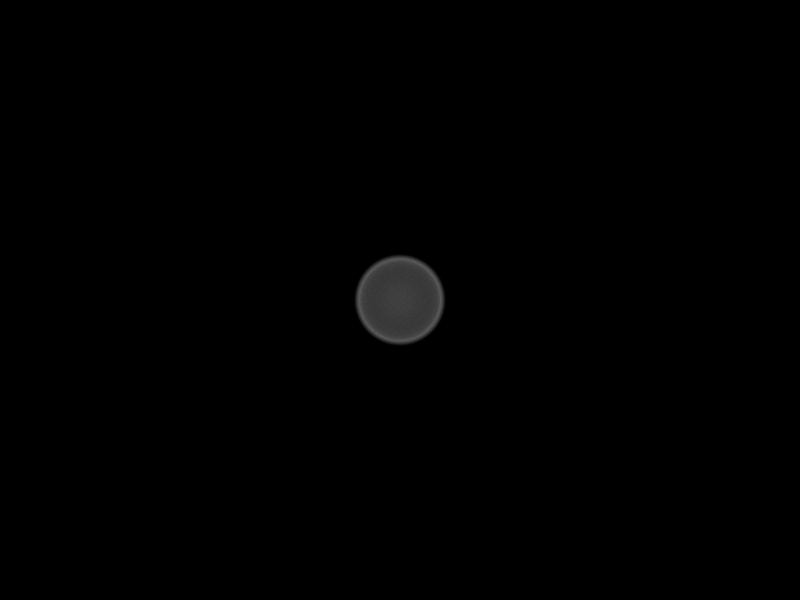

In [18]:
from IPython.display import display

first_series, data = next(iter(grouped_images.items()))
print(f"Sample series: {first_series}")
display(data["images"][0])

## Determine positions and write to text file

In [19]:
import numpy as np

records = []
positions = {}
skipped_edge = []
skipped_empty = []
for data in grouped_images.values():
    for path, image in zip(data["paths"], data["images"]):
        arr = to_linear_luminance(image)
        if not np.any(arr > 0.0):
            skipped_empty.append(path.name)
            continue
        total = float(arr.sum())
        if total <= 0.0:
            skipped_empty.append(path.name)
            continue
        height, width = arr.shape
        nonzero = np.argwhere(arr > 0.0)
        min_y, min_x = nonzero.min(axis=0)
        max_y, max_x = nonzero.max(axis=0)
        if min_x == 0 or min_y == 0 or max_x == width - 1 or max_y == height - 1:
            skipped_edge.append(path.name)
            continue
        y_idx, x_idx = np.indices(arr.shape)
        cx = float((arr * x_idx).sum() / total)
        cy = float((arr * y_idx).sum() / total)
        center_x, center_y = width / 2.0, height / 2.0
        dir_x, dir_y = width - 1 - center_x, -center_y
        vec_x, vec_y = cx - center_x, cy - center_y
        denom = dir_x * dir_x + dir_y * dir_y
        t = (vec_x * dir_x + vec_y * dir_y) / denom if denom else 0.0
        t_clamped = float(np.clip(t, 0.0, 1.0))
        records.append(f"{path.name},{t_clamped:.3f}\n")
        positions[path.name] = t_clamped

output_path = croppedWithPositions_dir / "positions.txt"
output_path.write_text("".join(records), encoding="utf-8")
print(f"Saved {len(records)} entries to {output_path}")
if skipped_edge:
    print(f"Skipped {len(skipped_edge)} shapes touching image edges.")
if skipped_empty:
    print(f"Skipped {len(skipped_empty)} empty or zero-intensity shapes.")

Saved 13 entries to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\2_cropped\positions.txt
Skipped 2 shapes touching image edges.


In [20]:
try:
    positions
except NameError as exc:
    raise RuntimeError("Run the position analysis cell before collecting intensities.") from exc

intensities = {}
skipped_unmatched = []
for data in grouped_images.values():
    for path, image in zip(data["paths"], data["images"]):
        if path.name not in positions:
            skipped_unmatched.append(path.name)
            continue
        linear_gray = to_linear_luminance(image)
        total_linear = float(linear_gray.sum())
        if total_linear <= 0.0:
            continue
        intensities[path.name] = total_linear
        total = int(np.rint(total_linear * 255.0))
        print(f"{path.name},{total}")
if skipped_unmatched:
    print(f"Skipped {len(skipped_unmatched)} shapes excluded during position analysis.")

bokeh_fl45.0_as6_samples1000000_od400_lidx0of15.png,390271
bokeh_fl45.0_as6_samples1000000_od400_lidx1of15.png,383157
bokeh_fl45.0_as6_samples1000000_od400_lidx2of15.png,376861
bokeh_fl45.0_as6_samples1000000_od400_lidx3of15.png,368570
bokeh_fl45.0_as6_samples1000000_od400_lidx4of15.png,354499
bokeh_fl45.0_as6_samples1000000_od400_lidx5of15.png,337833
bokeh_fl45.0_as6_samples1000000_od400_lidx6of15.png,319940
bokeh_fl45.0_as6_samples1000000_od400_lidx7of15.png,300371
bokeh_fl45.0_as6_samples1000000_od400_lidx8of15.png,280446
bokeh_fl45.0_as6_samples1000000_od400_lidx9of15.png,259765
bokeh_fl45.0_as6_samples1000000_od400_lidx10of15.png,238552
bokeh_fl45.0_as6_samples1000000_od400_lidx11of15.png,218132
bokeh_fl45.0_as6_samples1000000_od400_lidx12of15.png,196333
Skipped 2 shapes excluded during position analysis.


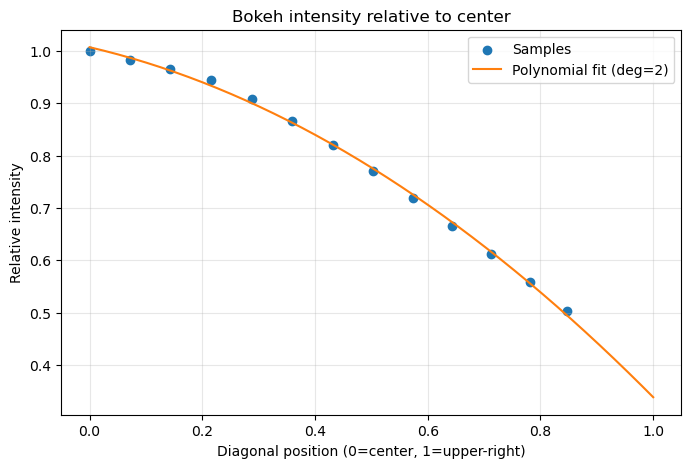

Polynomial coefficients (highest degree first): [-0.41720654 -0.25085544  1.00672758]
As function: bokeh_intensity(x) = -0.417207 * x^2 + -0.250855 * x + 1.00673
Center intensity used for normalization: 1530.474510


In [21]:
import matplotlib.pyplot as plt
import numpy as np

if not positions or not intensities:
    raise RuntimeError("Run the position and intensity cells first to populate the data.")

samples = []
missing = []
for name, pos in positions.items():
    intensity = intensities.get(name)
    if intensity is None:
        missing.append(name)
        continue
    samples.append((pos, intensity))

if not samples:
    raise RuntimeError("No overlapping position and intensity measurements were found.")

samples.sort(key=lambda item: item[0])
position_values = np.array([item[0] for item in samples], dtype=np.float64)
intensity_values = np.array([item[1] for item in samples], dtype=np.float64)

center_index = int(np.argmin(np.abs(position_values)))
center_intensity = intensity_values[center_index]
relative_intensity = intensity_values / center_intensity

poly_degree = 2
poly_coeffs = np.polyfit(position_values, relative_intensity, deg=poly_degree)
fit_grid = np.linspace(0.0, 1.0, num=200, dtype=np.float64)
fit_curve = np.polyval(poly_coeffs, fit_grid)

plt.figure(figsize=(8, 5))
plt.scatter(position_values, relative_intensity, label="Samples", color="#1f77b4")
plt.plot(fit_grid, fit_curve, label=f"Polynomial fit (deg={poly_degree})", color="#ff7f0e")
plt.xlabel("Diagonal position (0=center, 1=upper-right)")
plt.ylabel("Relative intensity")
plt.title("Bokeh intensity relative to center")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

def bokeh_intensity(position: float) -> float:
    """Interpolated relative intensity for a normalized position in [0, 1]."""
    clamped = float(np.clip(position, 0.0, 1.0))
    return float(np.polyval(poly_coeffs, clamped))

powers = np.arange(poly_coeffs.size - 1, -1, -1)
terms = []
for coeff, power in zip(poly_coeffs, powers):
    if abs(coeff) < 1e-12:
        continue
    if power == 0:
        terms.append(f"{coeff:.6g}")
    elif power == 1:
        terms.append(f"{coeff:.6g} * x")
    else:
        terms.append(f"{coeff:.6g} * x^{power}")
function_repr = " + ".join(terms) if terms else "0"

print("Polynomial coefficients (highest degree first):", poly_coeffs)
print(f"As function: bokeh_intensity(x) = {function_repr}")
print(f"Center intensity used for normalization: {center_intensity:.6f}")
if missing:
    print(f"Skipped {len(missing)} entries without intensity data.")

### Crop bokeh and save as .pgm

In [22]:
import numpy as np
from pathlib import Path

def save_pgm_ascii(path: Path, data: np.ndarray, max_value: int = 255) -> None:
    array = np.asarray(data)
    if array.ndim != 2:
        raise ValueError("PGM images must be 2D arrays")
    clipped = np.clip(array, 0, max_value).astype(np.uint8)
    height, width = clipped.shape
    header = f"P2\n{width} {height}\n{max_value}\n"
    body = "\n".join(" ".join(str(int(pixel)) for pixel in row) for row in clipped)
    path.write_text(header + body + "\n", encoding="ascii")

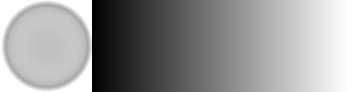

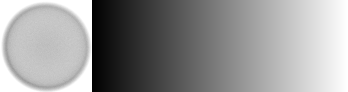

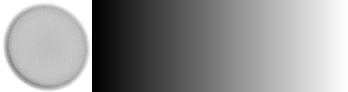

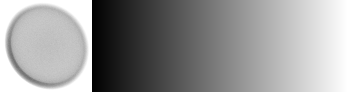

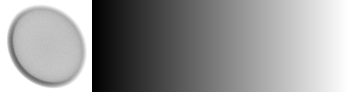

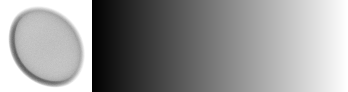

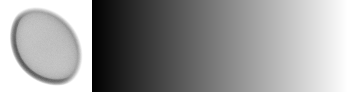

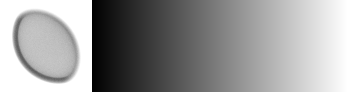

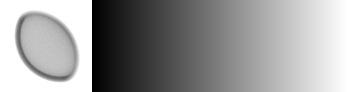

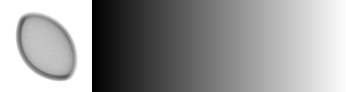

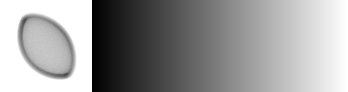

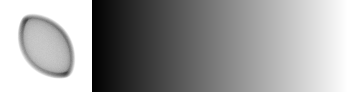

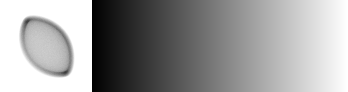

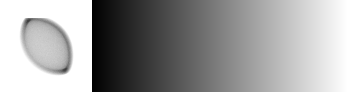

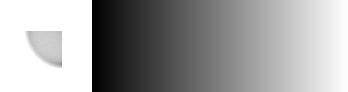

In [23]:
from PIL import ImageOps
from IPython.display import display

crop_boxes = {}
reference_side = None
gradient_width = 256

for data in grouped_images.values():
    for path, image in zip(data["paths"], data["images"]):
        linear_gray = to_linear_luminance(image)
        gray_image = linear_luminance_to_image(linear_gray)
        ys, xs = np.nonzero(linear_gray > 0.0)
        if ys.size:
            cx, cy = xs.mean(), ys.mean()
            side = max(int(round(max(np.ptp(xs), np.ptp(ys))) + 1), 1)
        else:
            height, width = linear_gray.shape
            cy, cx, side = height / 2.0, width / 2.0, max(1, min(height, width))
        reference_side = reference_side or side
        side = min(reference_side, linear_gray.shape[0], linear_gray.shape[1])
        half = side / 2.0
        left, top = int(round(cx - half)), int(round(cy - half))
        right, bottom = left + side, top + side
        padding = (
            max(0, -left),
            max(0, -top),
            max(0, right - linear_gray.shape[1]),
            max(0, bottom - linear_gray.shape[0]),
        )
        padded = ImageOps.expand(gray_image, border=padding, fill=0) if any(padding) else gray_image
        box = (
            left + padding[0],
            top + padding[1],
            right + padding[0],
            bottom + padding[1],
        )
        crop_boxes[path] = (padding, box)
        cropped = padded.crop(box)
        inverted = ImageOps.invert(cropped)
        gradient_linear = np.linspace(0.0, 1.0, num=gradient_width, dtype=np.float64)
        gradient_linear = np.tile(gradient_linear, (inverted.height, 1))
        gradient_image = linear_luminance_to_image(gradient_linear)
        combined = Image.new("L", (inverted.width + gradient_image.width, inverted.height))
        combined.paste(inverted, (0, 0))
        combined.paste(gradient_image, (inverted.width, 0))
        display(combined)
        save_pgm_ascii(croppedWithPositions_dir / f"{path.stem}.pgm", np.asarray(inverted))

### Save cropped bokeh as weights

In [24]:
for data in grouped_images.values():
    for path, image in zip(data["paths"], data["images"]):
        linear_gray = to_linear_luminance(image)
        gray_image = linear_luminance_to_image(linear_gray)
        record = crop_boxes.get(path)
        if record is None:
            target = gray_image
        else:
            padding, box = record
            padded = ImageOps.expand(gray_image, border=padding, fill=0) if any(padding) else gray_image
            target = padded.crop(box)
        target.save(weights_dir / f"{path.stem}.png", format="PNG")

### Generate batch scripts to process all the noise maps

In [31]:
bat_path = working_dir / "3_generate_blue_noise.bat"

lines = []
pgm_file = sorted(croppedWithPositions_dir.glob("*.pgm"))[0]
stem = pgm_file.stem
lines.append(
    f"for /l %%x in (0, 1, 31) do ..\\Utils\\agbn\\agbn.exe -F 0 -o {croppedWithPositions_dir / stem}.pgm 16384 1000 {blue_noise_dir / stem}_%%x.txt {blue_noise_dir / stem}_%%x.png"
)
bat_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {len(lines)} commands to {bat_path}")

Wrote 1 commands to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\3_generate_blue_noise.bat


In [ ]:
bat_path = working_dir / "4_pack_blue_noise_to_bin.bat"

lines = []
pgm_file = sorted(croppedWithPositions_dir.glob("*.pgm"))[0]
stem = pgm_file.stem
lines.append(
    f"..\\Utils\\Gbn2Bin\\x64\\Release\\Gbn2Bin.exe {blue_noise_dir / stem}_ {blue_noise_bin_dir / stem}"
)
bat_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {len(lines)} commands to {bat_path}")

Wrote 15 commands to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\4_pack_blue_noise_to_bin.bat


In [27]:
bat_path = working_dir / "5_make_fast_noise.bat"
fastnoise_root = working_dir.parent.parent / "fastnoise"
fast_noise_dir.mkdir(exist_ok=True)

lines = []
jobs = 0
for bin_file in sorted(blue_noise_bin_dir.glob("*.bin")):
    stem = bin_file.stem
    lines.extend(
        [
            f"pushd \"{fastnoise_root}\"",
            (
                "FastNoise.exe Vector2 Uniform gauss 1.0 exponential 0.1 0.1 separate -output exr"
                f"0.5 128 128 32 {stem} -split -init \"{blue_noise_bin_dir / stem}.bin\" -progress 1"
            ),
            f"for %%f in (\"{stem}*\") do move /Y \"%%f\" \"{fast_noise_dir}\"",
            "popd",
        ]
    )
    jobs += 1

bat_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Prepared {jobs} FastNoise runs in {bat_path}")

Prepared 0 FastNoise runs in C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\5_make_fast_noise.bat
